<h1><b>Rail Corrugation Exploratory Data Analysis</b></h1>

<h4><b>Background Information</b></h4>

NEBULA X Problem Statement 3 uses axle-box vibration and shock recordings to distinguish Normal rail conditions from Side I and Side II corrugation. Odd-numbered axle-box positions correspond to Side I; even-numbered positions correspond to Side II.

<h4><b>Objective</b></h4>

This notebook validates recordings, investigates side-specific signatures and speed-related confounding, and identifies candidate feature families and validation requirements. The analysis does not train models or assign Test labels.

<h4><b>Project Workflow</b></h4>

The workflow checks files, labels, schemas, and sample quality; summarises sensor channels and speed pulses; compares temporal and spectral patterns; examines outliers, redundancy, and Train/Test coverage; and prepares recording-level validation.

<h4><b>Dataset Used</b></h4>

`PS3/02_Datasets/Rail_Corrugation` contains Train and Test CSV recordings and `Train_Labels.csv`. The information kit specifies 272 Train files, 68 Test files, 10,000 samples per file, and a 10,000 Hz sampling rate. Each file has a binary rotational-sensor channel and 128 acceleration channels: vibration and shock at 64 axle boxes across eight cars. Acceleration units are m/s².

The authoritative schema, side mapping, and macro-F1 metric are defined in `PS3/03_References/Rail_Corrugation/Rail_Corrugation_Info_Kit.md`. Numeric filenames are identifiers; recording chronology and source-session grouping are not established.

<h4><b>Table of Contents</b></h4>
<ul>
  <li><a href="#section-1">Section 1: Environment Setup and Configuration</a>
    <ul>
      <li><a href="#1-1">1.1 Libraries and Dataset Paths</a></li>
    </ul>
  </li>
  <li><a href="#section-2">Section 2: Dataset Inventory and Label Integrity</a>
    <ul>
      <li><a href="#2-1">2.1 Inventory and Label Alignment</a></li>
      <li><a href="#2-2">2.2 Header Parsing and Sample Inspection</a></li>
    </ul>
  </li>
  <li><a href="#section-3">Section 3: Complete Recording Audit and Summary Extraction</a>
    <ul>
      <li><a href="#3-1">3.1 Descriptor Definitions</a></li>
      <li><a href="#3-2">3.2 Streaming File Audit</a></li>
      <li><a href="#3-3">3.3 Duplicates and Sensor Quality Screens</a></li>
    </ul>
  </li>
  <li><a href="#section-4">Section 4: Class Imbalance and Speed Context</a>
    <ul>
      <li><a href="#4-1">4.1 Class Counts and Metric Context</a></li>
      <li><a href="#4-2">4.2 Pulse-Derived Speed and Confounding</a></li>
    </ul>
  </li>
  <li><a href="#section-5">Section 5: Temporal and Spatial Signal Patterns</a>
    <ul>
      <li><a href="#5-1">5.1 Representative Channel Traces</a></li>
      <li><a href="#5-2">5.2 Class-Level Sensor Maps</a></li>
    </ul>
  </li>
  <li><a href="#section-6">Section 6: Spectral Analysis and Side-Specific Features</a>
    <ul>
      <li><a href="#6-1">6.1 Median Spectral Profiles</a></li>
      <li><a href="#6-2">6.2 Recording-Level Feature Assembly</a></li>
      <li><a href="#6-3">6.3 Side Asymmetry and Class Distributions</a></li>
    </ul>
  </li>
  <li><a href="#section-7">Section 7: Outlier Review and Feature Dependence</a>
    <ul>
      <li><a href="#7-1">7.1 Normal-Reference Robust Outlier Screen</a></li>
      <li><a href="#7-2">7.2 Speed and Amplitude Relationships</a></li>
      <li><a href="#7-3">7.3 Feature Redundancy and Case-Level Uncertainty</a></li>
    </ul>
  </li>
  <li><a href="#section-8">Section 8: Train and Test Coverage</a>
    <ul>
      <li><a href="#8-1">8.1 Feature Range and Median Shifts</a></li>
    </ul>
  </li>
  <li><a href="#section-9">Section 9: Validation Planning and Leakage Controls</a>
    <ul>
      <li><a href="#9-1">9.1 Provisional Stratified File Folds</a></li>
      <li><a href="#9-2">9.2 Modelling Handoff</a></li>
    </ul>
  </li>
  <li><a href="#section-10">Section 10: Verified Findings and Conclusions</a>
    <ul>
      <li><a href="#10-1">10.1 Reproducible Results Summary</a></li>
      <li><a href="#10-2">10.2 Observed Results</a></li>
      <li><a href="#10-3">10.3 Limitations and Next Modelling Decisions</a></li>
    </ul>
  </li>
</ul>

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-1" style="color: black;"><b>Section 1: Environment Setup and Configuration</b></h2>
</div>

This section configures dependencies, source paths, physical constants supplied by the information kit, and plotting settings.

<blockquote><h3 id="1-1"><b>1.1 Libraries and Dataset Paths</b></h3></blockquote>

CSV files are processed one at a time to avoid holding several gigabytes of raw recordings in memory. Only compact summaries and selected examples are retained.

In [1]:
from pathlib import Path
import os, re, hashlib, json, platform
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, stats
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from IPython.display import display
FS=10000; TEETH=90; WHEEL_DIAMETER_M=.85; SEED=2026
CLASSES=['Normal','Side I','Side II']
COLORS={'Normal':'#16857b','Side I':'#d95f38','Side II':'#2878a5','Test':'#8256b3'}
plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False,'figure.constrained_layout.use':True})
pd.set_option('display.max_columns',30); pd.set_option('display.max_rows',70)
def find_rail():
    candidates=[Path(os.environ['TFD_PS3_DIR']).expanduser()/'02_Datasets/Rail_Corrugation'] if os.environ.get('TFD_PS3_DIR') else [p/q for p in [Path.cwd(),*Path.cwd().parents] for q in ['PS3/02_Datasets/Rail_Corrugation','02_Datasets/Rail_Corrugation']]
    return next(p.resolve() for p in candidates if (p/'Train_Labels.csv').is_file())
RAIL_DIR=find_rail()
display(pd.Series({'Python':platform.python_version(),**{p:importlib.metadata.version(p) for p in ['numpy','pandas','scipy','matplotlib','scikit-learn']}}))

Python          3.13.7
numpy            2.5.3
pandas           3.0.5
scipy           1.18.1
matplotlib      3.11.2
scikit-learn     1.9.1
dtype: str

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-2" style="color: black;"><b>Section 2: Dataset Inventory and Label Integrity</b></h2>
</div>

This section establishes recording counts, validates labels by filename, and checks the documented channel layout before numerical analysis.

<blockquote><h3 id="2-1"><b>2.1 Inventory and Label Alignment</b></h3></blockquote>

Observed class counts are authoritative for this copy of the dataset because illustrative counts elsewhere in the information kit differ. Filename matching prevents accidental label alignment by file order.

In [2]:
paths={s:sorted((RAIL_DIR/s).glob('*.csv')) for s in ['Train','Test']}
inventory=pd.DataFrame([{'dataset':s,'filename':p.name,'size_MB':p.stat().st_size/1e6} for s,files in paths.items() for p in files])
labels=pd.read_csv(RAIL_DIR/'Train_Labels.csv')
display(inventory.groupby('dataset').agg(files=('filename','size'),total_MB=('size_MB','sum')))
display(labels.head()); display(labels.label.value_counts().reindex(CLASSES))
assert labels.filename.is_unique and not labels.isna().any().any()
assert set(labels.filename)=={p.name for p in paths['Train']}
assert set(labels.label)==set(CLASSES)
labels=labels.set_index('filename')

,files,total_MB
dataset,,
Test,68,1176.546965
Train,272,4707.527671


,filename,label
0,Train1.csv,Normal
1,Train2.csv,Side II
2,Train3.csv,Normal
3,Train4.csv,Normal
4,Train5.csv,Normal


label
Normal     234
Side I      14
Side II     24
Name: count, dtype: int64

<blockquote><h3 id="2-2"><b>2.2 Header Parsing and Sample Inspection</b></h3></blockquote>

Channel meaning is parsed from complete names rather than inferred solely from column offsets. Each combination of car, position, and sensor type must appear once.

In [3]:
sample=pd.read_csv(paths['Train'][0])
SPEED='Rotating speed'
channel_rows=[]
for column in sample.columns[1:]:
    match=re.fullmatch(r'(Vibration|Shock) of bearing in position (\d+) of car (\d+)',column)
    assert match, f'Unexpected channel: {column}'
    kind,position,car=match.groups(); position=int(position); car=int(car)
    channel_rows.append({'column':column,'kind':kind,'car':car,'position':position,'side':'Side I' if position%2 else 'Side II'})
channel_map=pd.DataFrame(channel_rows)
expected={(car,pos,kind) for car in range(1,9) for pos in range(1,9) for kind in ['Vibration','Shock']}
assert sample.columns[0]==SPEED and len(channel_map)==128
assert set(map(tuple,channel_map[['car','position','kind']].to_numpy()))==expected
assert not channel_map.duplicated(['car','position','kind']).any()
display(channel_map.head(10)); display(sample.iloc[:5,:7]); display(sample.dtypes.astype(str).value_counts().rename('columns'))

,column,kind,car,position,side
0,Vibration of bearing in position 1 of car 1,Vibration,1,1,Side I
1,Shock of bearing in position 1 of car 1,Shock,1,1,Side I
2,Vibration of bearing in position 2 of car 1,Vibration,1,2,Side II
3,Shock of bearing in position 2 of car 1,Shock,1,2,Side II
4,Vibration of bearing in position 3 of car 1,Vibration,1,3,Side I
5,Shock of bearing in position 3 of car 1,Shock,1,3,Side I
6,Vibration of bearing in position 4 of car 1,Vibration,1,4,Side II
7,Shock of bearing in position 4 of car 1,Shock,1,4,Side II
8,Vibration of bearing in position 5 of car 1,Vibration,1,5,Side I
9,Shock of bearing in position 5 of car 1,Shock,1,5,Side I


,Rotating speed,Vibration of bearing in position 1 of car 1,Shock of bearing in position 1 of car 1,Vibration of bearing in position 2 of car 1,Shock of bearing in position 2 of car 1,Vibration of bearing in position 3 of car 1,Shock of bearing in position 3 of car 1
0,0,-0.036621,-0.476074,-0.048828,-0.585938,-0.012207,-0.573730
1,0,-0.036621,-0.476074,-0.036621,-0.561523,-0.012207,-0.561523
2,0,-0.012207,-0.500488,-0.061035,-0.573730,-0.012207,-0.585938
3,0,-0.012207,-0.537109,-0.061035,-0.524902,-0.012207,-0.598145
4,0,0.000000,-0.549316,-0.085449,-0.537109,0.000000,-0.598145


float64    128
int64        1
Name: columns, dtype: int64

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-3" style="color: black;"><b>Section 3: Complete Recording Audit and Summary Extraction</b></h2>
</div>

This section scans every supplied recording for quality issues and computes transparent channel-level descriptors. No samples are removed, clipped, interpolated, or normalised in the stored raw files.

<blockquote><h3 id="3-1"><b>3.1 Descriptor Definitions</b></h3></blockquote>

Acceleration summaries include raw RMS, demeaned RMS, peak, crest factor, and excess kurtosis. Welch spectra are computed per channel before side aggregation to avoid waveform cancellation. Broad frequency bands are exploratory, not verified corrugation bands.

In [4]:
BANDS=[(0,100,'0_100'),(100,500,'100_500'),(500,1500,'500_1500'),(1500,5001,'1500_5000')]
def describe_channels(x):
    """Summarise an (n_samples, n_channels) finite acceleration matrix."""
    mean=x.mean(axis=0); centered=x-mean
    rms=np.sqrt(np.mean(centered**2,axis=0)); peak=np.max(abs(centered),axis=0)
    result=pd.DataFrame({'mean':mean,'raw_rms':np.sqrt(np.mean(x*x,axis=0)), 'ac_rms':rms,
        'abs_p99':np.quantile(abs(centered),.99,axis=0),'peak':peak,
        'crest':np.divide(peak,rms,out=np.full_like(rms,np.nan),where=rms>0),
        'kurtosis':stats.kurtosis(x,axis=0),
        'equal_step_fraction':np.mean(np.diff(x,axis=0)==0,axis=0),
        'endpoint_fraction':np.mean((x==x.min(axis=0))|(x==x.max(axis=0)),axis=0)})
    f,p=signal.welch(x,fs=FS,nperseg=1024,noverlap=512,axis=0,detrend='constant')
    power=p.sum(axis=0)
    result['spectral_centroid']=np.divide((f[:,None]*p).sum(axis=0),power,out=np.full_like(power,np.nan),where=power>0)
    result['peak_frequency']=f[1:][np.argmax(p[1:],axis=0)]
    for lo,hi,name in BANDS:
        result['band_'+name]=np.divide(p[(f>=lo)&(f<hi)].sum(axis=0),power,out=np.full_like(power,np.nan),where=power>0)
    return result,f,p

<blockquote><h3 id="3-2"><b>3.2 Streaming File Audit</b></h3></blockquote>

The audit verifies numeric conversion, sample count, finite readings, binary pulse values, and channel coverage. Exact duplicate numeric recordings are fingerprinted. Endpoint repetition is a clipping screen only because sensor saturation limits are undocumented. Progress is printed every 50 files.

In [5]:
quality_rows=[]; channel_tables=[]; speed_rows=[]; psd_summaries={}; examples={}
example_names={label:labels.index[labels.label.eq(label)][0] for label in CLASSES}
all_files=[(s,p) for s,files in paths.items() for p in files]
for number,(split,path) in enumerate(all_files,1):
    frame=pd.read_csv(path)
    assert set(frame.columns)==set(sample.columns) and len(frame.columns)==129, path.name
    ordered=frame[[SPEED]+channel_map.column.tolist()]
    numeric=ordered.apply(pd.to_numeric,errors='coerce')
    arr=numeric.to_numpy(dtype=float)
    missing=int(ordered.isna().sum().sum()); coercion=int((numeric.isna()&ordered.notna()).sum().sum())
    quality_rows.append({'dataset':split,'filename':path.name,'rows':len(frame),'columns':len(frame.columns),
        'missing':missing,'nonnumeric':coercion,'infinite':int(np.isinf(arr).sum()),
        'constant_acceleration_channels':int(np.ptp(arr[:,1:],axis=0).tolist().count(0)),
        'numeric_hash':hashlib.sha256(arr.astype('<f8').tobytes()).hexdigest(),
        'acceleration_hash':hashlib.sha256(arr[:,1:].astype('<f8').tobytes()).hexdigest()})
    assert np.isfinite(arr).all() and len(frame)==10000, f'Review invalid or unexpected-length file: {path.name}'
    pulse=arr[:,0]; assert set(np.unique(pulse))<={0,1}, path.name
    edges=np.diff(pulse); elapsed=(len(pulse)-1)/FS
    rising=int((edges==1).sum()); falling=int((edges==-1).sum())
    intervals=np.diff(np.flatnonzero(edges==1))/FS
    speed_rows.append({'dataset':split,'filename':path.name,'rising_edges':rising,'falling_edges':falling,
        'pulse_high_fraction':pulse.mean(),'rising_interval_cv':intervals.std()/intervals.mean() if len(intervals)>1 else np.nan,
        'speed_kmh_rising':rising/elapsed/TEETH*np.pi*WHEEL_DIAMETER_M*3.6,
        'speed_kmh_both_edges':(rising+falling)/elapsed/(2*TEETH)*np.pi*WHEEL_DIAMETER_M*3.6})
    descriptor,f,p=describe_channels(arr[:,1:])
    descriptor=pd.concat([channel_map,descriptor],axis=1)
    descriptor['filename']=path.name; descriptor['dataset']=split
    channel_tables.append(descriptor)
    for (side,kind),g in channel_map.groupby(['side','kind']):
        psd_summaries[(split,path.name,side,kind)]=np.median(p[:,g.index],axis=1)
    if split=='Train' and path.name in example_names.values(): examples[path.name]=arr.copy()
    if number%50==0 or number==len(all_files): print(f'Processed {number}/{len(all_files)} recordings')
quality=pd.DataFrame(quality_rows); channels=pd.concat(channel_tables,ignore_index=True)
speed=pd.DataFrame(speed_rows).set_index(['dataset','filename'])
frequencies=f
display(quality.groupby('dataset').agg(files=('filename','size'),min_rows=('rows','min'),max_rows=('rows','max'),
    missing=('missing','sum'),nonnumeric=('nonnumeric','sum'),infinite=('infinite','sum'),constant_channels=('constant_acceleration_channels','sum')))

Processed 50/340 recordings


Processed 100/340 recordings


Processed 150/340 recordings


Processed 200/340 recordings


Processed 250/340 recordings


Processed 300/340 recordings


Processed 340/340 recordings


,files,min_rows,max_rows,missing,nonnumeric,infinite,constant_channels
dataset,,,,,,,
Test,68,10000,10000,0,0,0,0
Train,272,10000,10000,0,0,0,0


<blockquote><h3 id="3-3"><b>3.3 Duplicates and Sensor Quality Screens</b></h3></blockquote>

Exact full-recording and acceleration-only duplicates are reported separately. Channel-level extremes and repeated endpoints guide inspection; a large signal can be a fault signature and is not automatically discarded.

In [6]:
duplicates=quality.loc[quality.duplicated('numeric_hash',keep=False),['dataset','filename','numeric_hash']]
acceleration_duplicates=quality.loc[quality.duplicated('acceleration_hash',keep=False),['dataset','filename','acceleration_hash']]
display(duplicates); display(acceleration_duplicates)
display(channels.nlargest(12,'endpoint_fraction')[['dataset','filename','kind','car','position','ac_rms','endpoint_fraction','equal_step_fraction']])
display(channels.nlargest(12,'peak')[['dataset','filename','kind','car','position','peak','crest','kurtosis']])

,dataset,filename,numeric_hash
9,Train,Train107.csv,13a1021d5f1059eb590bc9fe9c72b97854d618a4e86d99...
18,Train,Train115.csv,13a1021d5f1059eb590bc9fe9c72b97854d618a4e86d99...
73,Train,Train165.csv,2898adc5b199103ccf123c67870614cf50a221e4c1be3e...
97,Train,Train187.csv,2898adc5b199103ccf123c67870614cf50a221e4c1be3e...


,dataset,filename,acceleration_hash
9,Train,Train107.csv,c46885e25aa04ba3c1164a383d2d7a5ddfdf788834dc38...
18,Train,Train115.csv,c46885e25aa04ba3c1164a383d2d7a5ddfdf788834dc38...
73,Train,Train165.csv,107d42e5e38eeb0da6be6c2200b7da0619bf821db28886...
97,Train,Train187.csv,107d42e5e38eeb0da6be6c2200b7da0619bf821db28886...


,dataset,filename,kind,car,position,ac_rms,endpoint_fraction,equal_step_fraction
41688,Test,Test58.csv,Vibration,6,5,0.008479,0.0500,0.403340
33816,Train,Train92.csv,Vibration,2,5,0.007971,0.0479,0.429043
21762,Train,Train252.csv,Vibration,1,2,0.008301,0.0467,0.405441
31456,Train,Train75.csv,Vibration,7,1,0.008222,0.0467,0.409441
18372,Train,Train228.csv,Vibration,5,3,0.008135,0.0350,0.414941
18436,Train,Train229.csv,Vibration,1,3,0.008059,0.0346,0.424442
35650,Test,Test15.csv,Vibration,5,2,0.008531,0.0335,0.400440
21778,Train,Train252.csv,Vibration,2,2,0.008311,0.0319,0.412441
35708,Test,Test15.csv,Vibration,8,7,0.008991,0.0314,0.392839
28610,Train,Train55.csv,Vibration,5,2,0.008457,0.0307,0.400340


,dataset,filename,kind,car,position,peak,crest,kurtosis
23935,Train,Train267.csv,Shock,8,8,31.641981,6.510303,5.275610
31095,Train,Train72.csv,Shock,8,4,29.528693,6.524170,5.392110
767,Train,Train103.csv,Shock,8,8,29.366216,8.765300,13.776868
1071,Train,Train106.csv,Shock,3,8,28.549786,15.147130,57.911926
27055,Train,Train44.csv,Shock,3,8,28.458944,12.392672,20.172411
38643,Test,Test36.csv,Shock,8,2,28.416071,17.084909,52.064269
4487,Train,Train130.csv,Shock,1,4,28.053501,11.960500,19.631066
14127,Train,Train199.csv,Shock,3,8,27.827988,15.520193,40.517709
13483,Train,Train194.csv,Shock,3,6,27.657969,24.886985,196.914782
21665,Train,Train251.csv,Shock,3,1,27.641523,10.439186,10.999527


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-4" style="color: black;"><b>Section 4: Class Imbalance and Speed Context</b></h2>
</div>

This section establishes the effective labelled sample size and examines the binary speed channel as an operating-context variable.

<blockquote><h3 id="4-1"><b>4.1 Class Counts and Metric Context</b></h3></blockquote>

The official metric gives equal weight to each class through macro F1. An always-Normal reference is calculated only to illustrate why high accuracy can conceal failure on minority classes; no model is trained.

,files,share
label,,
Normal,234,0.860294
Side I,14,0.051471
Side II,24,0.088235


always_Normal_accuracy    0.860294
always_Normal_macro_F1    0.308300
dtype: float64

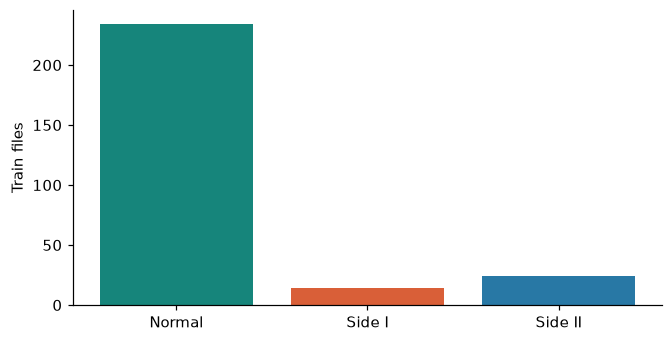

In [7]:
counts=labels.label.value_counts().reindex(CLASSES)
display(pd.DataFrame({'files':counts,'share':counts/len(labels)}))
always_normal=np.repeat('Normal',len(labels))
display(pd.Series({'always_Normal_accuracy':accuracy_score(labels.label,always_normal),
    'always_Normal_macro_F1':f1_score(labels.label,always_normal,labels=CLASSES,average='macro',zero_division=0)}))
fig,ax=plt.subplots(figsize=(6,3)); ax.bar(counts.index,counts.values,color=[COLORS[c] for c in counts.index]); ax.set(ylabel='Train files'); plt.show()

<blockquote><h3 id="4-2"><b>4.2 Pulse-Derived Speed and Confounding</b></h3></blockquote>

The speed proxy assumes one rising edge per tooth, 90 teeth per revolution, and a 0.85 m wheel diameter. A second estimate divides both edge types by 180 per revolution. Agreement checks counting consistency, not physical calibration. Short-window edge counts, slip, pulse aliasing, and the tooth convention limit accuracy.

speed_kmh_rising                       rising_interval_cv          
                     min     median        max             median       max
label                                                                      
Normal          0.000000  29.270004  70.183915           0.020384  0.516333
Side I         34.931720  46.629039  66.979170           0.019168  0.023236
Side II        42.088984  50.421321  66.658696           0.022048  0.028905

count    340.000000
mean       0.023093
std        0.026500
min        0.000000
25%        0.000000
50%        0.000000
75%        0.053412
max        0.053412
Name: edge_estimate_disagreement_kmh, dtype: float64

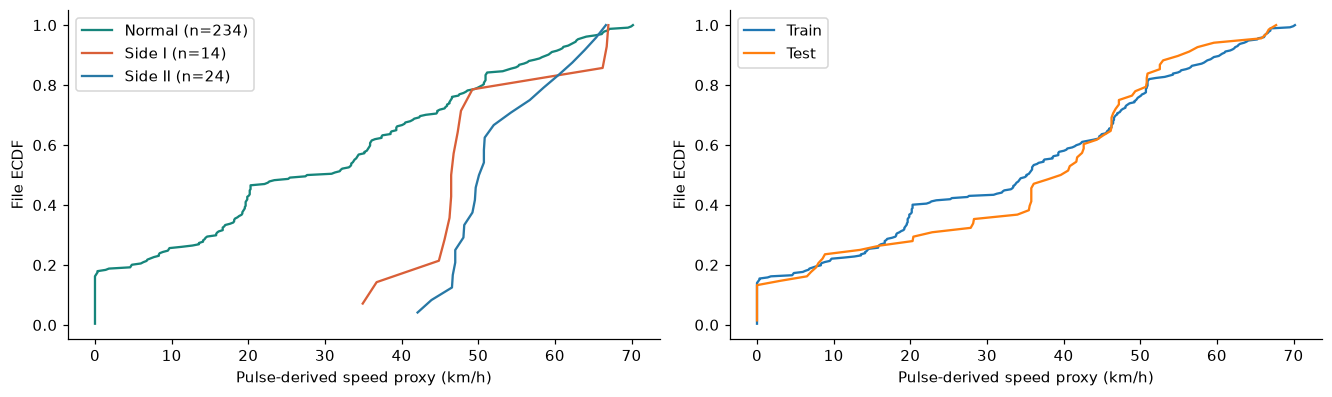

In [8]:
train_speed=speed.loc['Train'].join(labels)
display(train_speed.groupby('label').agg({'speed_kmh_rising':['min','median','max'],'rising_interval_cv':['median','max']}))
display((speed.speed_kmh_rising-speed.speed_kmh_both_edges).abs().describe().rename('edge_estimate_disagreement_kmh'))
fig,axes=plt.subplots(1,2,figsize=(12,3.5))
for label in CLASSES:
    s=train_speed.loc[train_speed.label.eq(label),'speed_kmh_rising']
    axes[0].plot(np.sort(s),np.arange(1,len(s)+1)/len(s),label=f'{label} (n={len(s)})',color=COLORS[label])
for split in ['Train','Test']:
    s=speed.loc[split].speed_kmh_rising
    axes[1].plot(np.sort(s),np.arange(1,len(s)+1)/len(s),label=split)
for ax in axes: ax.set(xlabel='Pulse-derived speed proxy (km/h)',ylabel='File ECDF'); ax.legend()
plt.show()

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-5" style="color: black;"><b>Section 5: Temporal and Spatial Signal Patterns</b></h2>
</div>

This section compares representative recordings and the spatial distribution of signal amplitudes across cars and axle positions.

<blockquote><h3 id="5-1"><b>5.1 Representative Channel Traces</b></h3></blockquote>

The first available file of each Train class is displayed using fixed car 1 positions 1 and 2. Examples are illustrative rather than representative of every labelled file. Short excerpts show individual samples without smoothing.

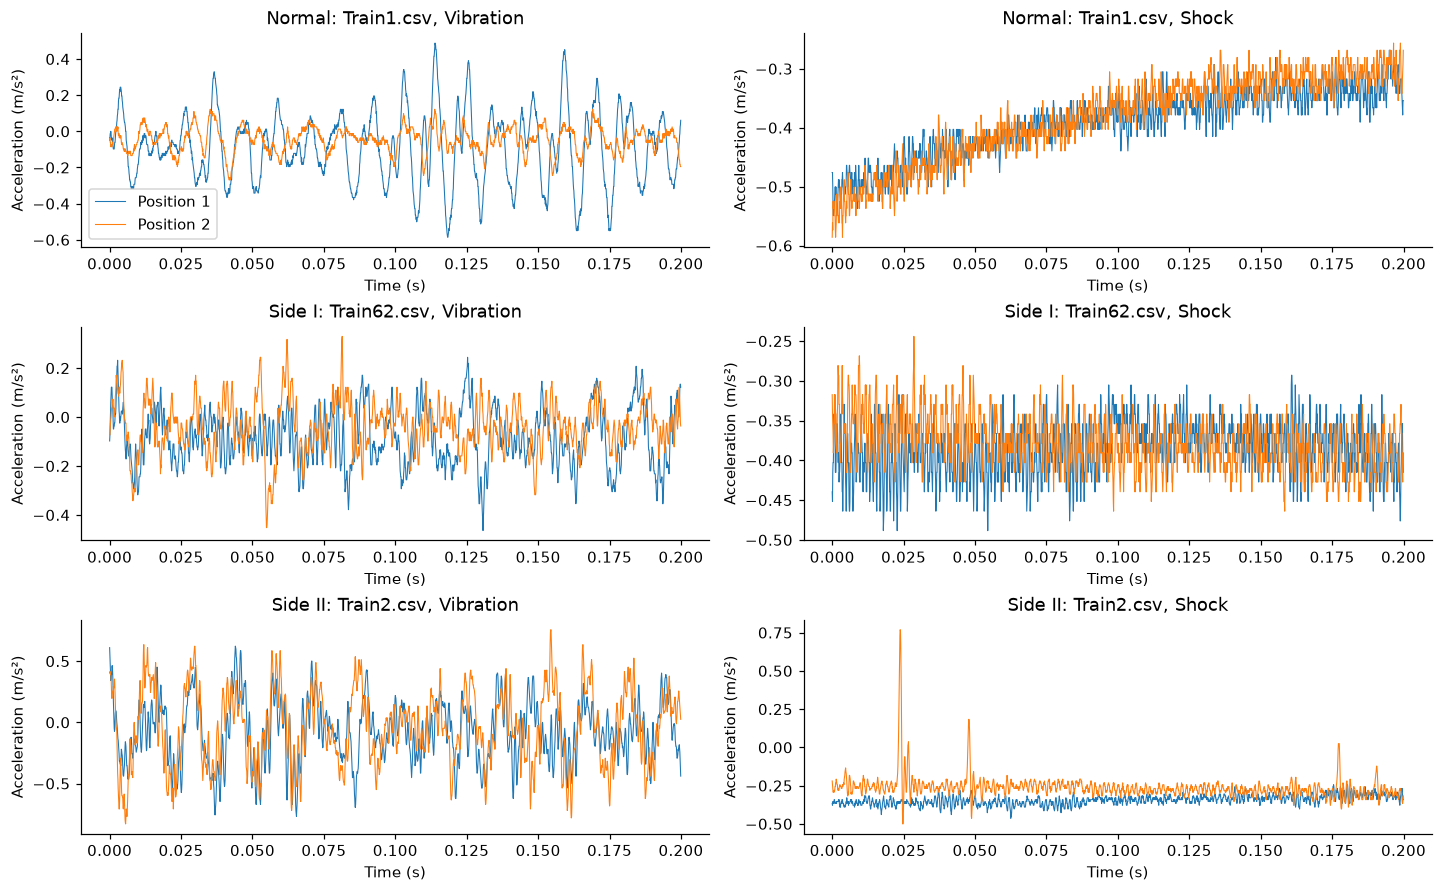

In [9]:
fig,axes=plt.subplots(3,2,figsize=(13,8))
for row,label in enumerate(CLASSES):
    name=example_names[label]; arr=examples[name]
    for ax,kind in zip(axes[row],['Vibration','Shock']):
        for position in [1,2]:
            idx=channel_map.index[(channel_map.car==1)&(channel_map.position==position)&(channel_map.kind==kind)][0]
            ax.plot(np.arange(2000)/FS,arr[:2000,idx+1],lw=.7,label=f'Position {position}')
        ax.set(title=f'{label}: {name}, {kind}',xlabel='Time (s)',ylabel='Acceleration (m/s²)')
axes[0,0].legend(); plt.show()

<blockquote><h3 id="5-2"><b>5.2 Class-Level Sensor Maps</b></h3></blockquote>

Median demeaned RMS is calculated across files for each sensor location. Logarithmic colour values allow different amplitude scales to be compared; channel values are not treated as independent labelled examples.

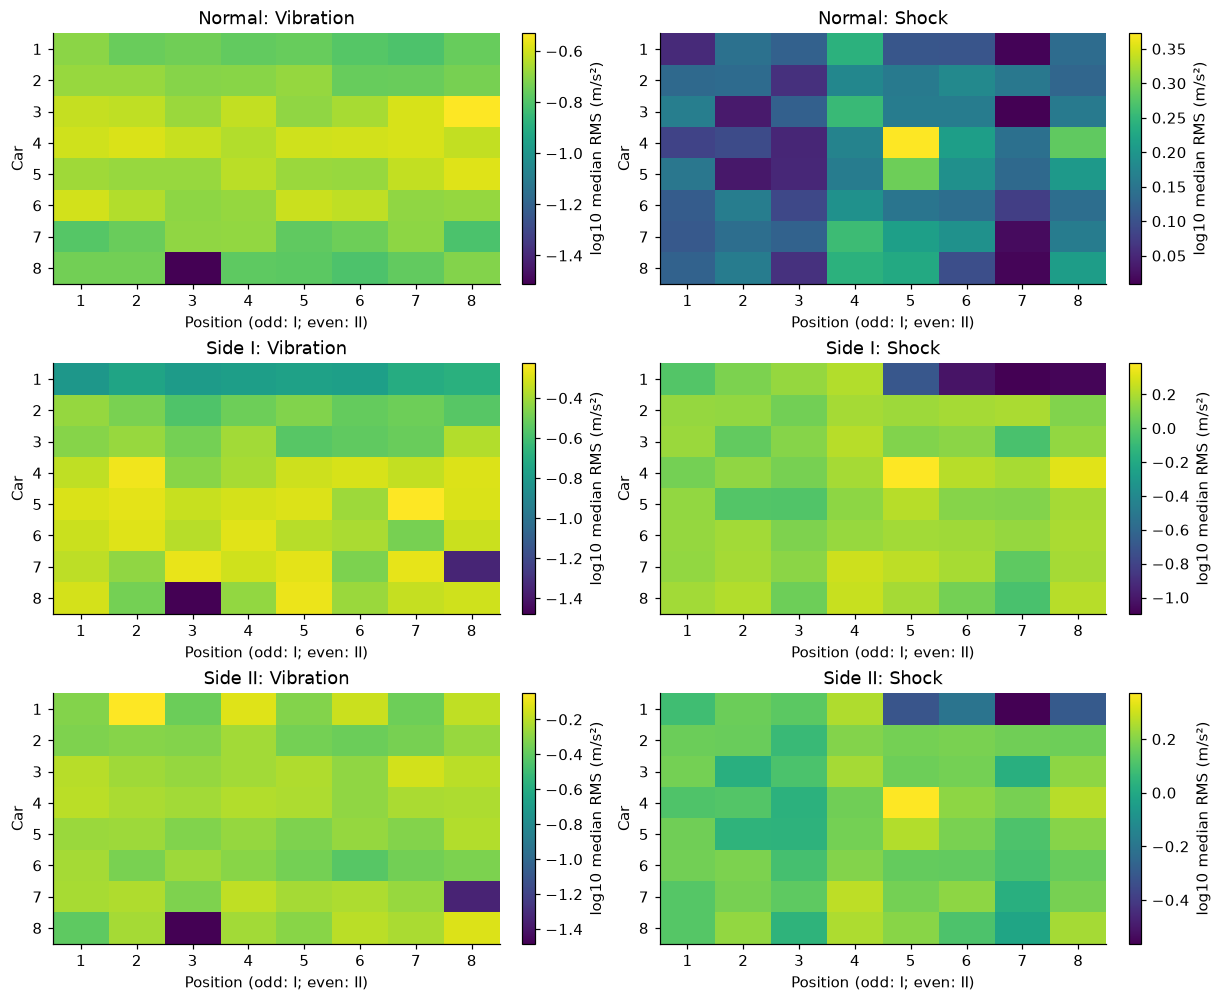

In [10]:
train_channels=channels.query("dataset == 'Train'").join(labels,on='filename')
fig,axes=plt.subplots(3,2,figsize=(11,9))
for row,label in enumerate(CLASSES):
    for col,kind in enumerate(['Vibration','Shock']):
        table=train_channels.query('label == @label and kind == @kind').groupby(['car','position']).ac_rms.median().unstack()
        im=axes[row,col].imshow(np.log10(table.where(table>0)),aspect='auto',cmap='viridis')
        axes[row,col].set(title=f'{label}: {kind}',xticks=range(8),xticklabels=range(1,9),yticks=range(8),yticklabels=range(1,9),xlabel='Position (odd: I; even: II)',ylabel='Car')
        fig.colorbar(im,ax=axes[row,col],label='log10 median RMS (m/s²)')
plt.show()

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-6" style="color: black;"><b>Section 6: Spectral Analysis and Side-Specific Features</b></h2>
</div>

This section preserves side identity while aggregating across sensors. Candidate features are descriptive; no thresholds or frequency bands are optimised against Test.

<blockquote><h3 id="6-1"><b>6.1 Median Spectral Profiles</b></h3></blockquote>

Each file contributes a median channel PSD for each side and sensor type. Class medians and interquartile bands are computed across files. Welch segments of 1,024 samples give approximately 9.77 Hz frequency spacing; spectral peaks are not automatically corrugation wavelengths.

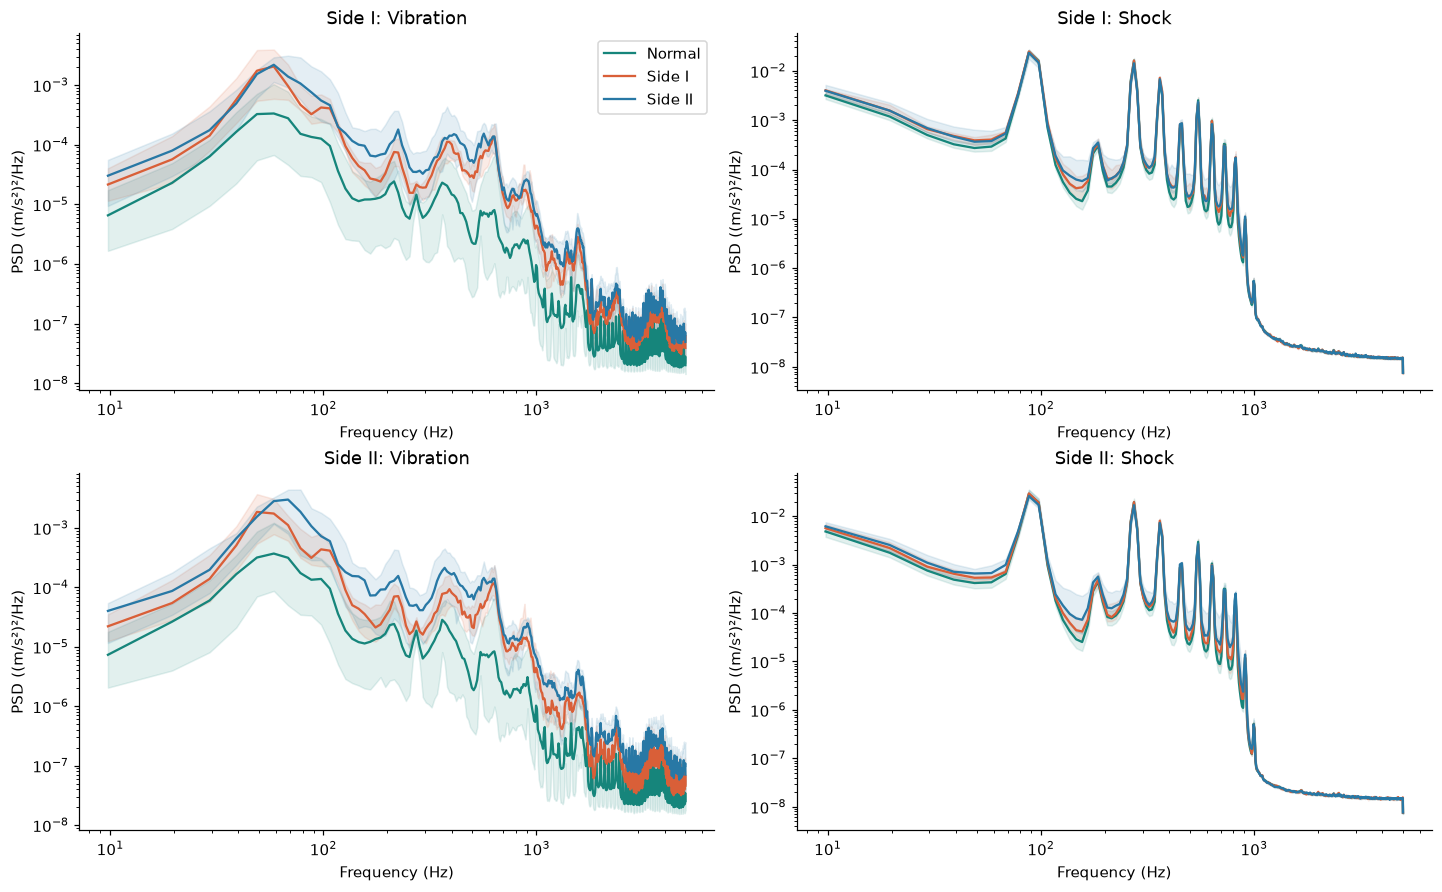

In [11]:
fig,axes=plt.subplots(2,2,figsize=(13,8))
for row,side in enumerate(['Side I','Side II']):
    for col,kind in enumerate(['Vibration','Shock']):
        ax=axes[row,col]
        for label in CLASSES:
            values=np.stack([psd_summaries[('Train',name,side,kind)] for name in labels.index[labels.label.eq(label)]])
            q1,med,q3=np.quantile(values,[.25,.5,.75],axis=0)
            ax.plot(frequencies[1:],med[1:],label=label,color=COLORS[label])
            ax.fill_between(frequencies[1:],q1[1:],q3[1:],color=COLORS[label],alpha=.12)
        ax.set(xscale='log',yscale='log',title=f'{side}: {kind}',xlabel='Frequency (Hz)',ylabel='PSD ((m/s²)²/Hz)')
axes[0,0].legend(); plt.show()

<blockquote><h3 id="6-2"><b>6.2 Recording-Level Feature Assembly</b></h3></blockquote>

Per-side sensor medians reduce single-sensor dominance, while maximum RMS retains localised amplitude information. Log side ratios preserve direction. Median-to-maximum comparisons and separate shock/vibration summaries can expose localisation lost by whole-train averaging.

In [12]:
METRICS=['ac_rms','peak','crest','kurtosis','spectral_centroid']+['band_'+name for _,_,name in BANDS]
rows=[]
for (split,name),group in channels.groupby(['dataset','filename']):
    record={'dataset':split,'filename':name}
    for kind in ['Vibration','Shock']:
        prefix=kind.lower()
        for side,tag in [('Side I','I'),('Side II','II')]:
            g=group.loc[(group.kind==kind)&(group.side==side)]
            for metric in METRICS: record[f'{prefix}_{tag}_{metric}']=g[metric].median()
            record[f'{prefix}_{tag}_max_rms']=g.ac_rms.max()
        a=record[f'{prefix}_I_ac_rms']; b=record[f'{prefix}_II_ac_rms']
        record[f'{prefix}_log_I_II_rms']=np.log(a/b) if a>0 and b>0 else np.nan
    rows.append(record)
features=pd.DataFrame(rows).set_index(['dataset','filename']).join(speed[['speed_kmh_rising']])
train_features=features.loc['Train'].join(labels); test_features=features.loc['Test']
FEATURES=list(features.columns)
display(features.isna().sum().loc[lambda s:s>0].rename('undefined_features'))
display(train_features.head())

Series([], Name: undefined_features, dtype: int64)

,vibration_I_ac_rms,vibration_I_peak,vibration_I_crest,vibration_I_kurtosis,vibration_I_spectral_centroid,vibration_I_band_0_100,vibration_I_band_100_500,vibration_I_band_500_1500,vibration_I_band_1500_5000,vibration_I_max_rms,vibration_II_ac_rms,vibration_II_peak,vibration_II_crest,vibration_II_kurtosis,vibration_II_spectral_centroid,...,shock_I_band_1500_5000,shock_I_max_rms,shock_II_ac_rms,shock_II_peak,shock_II_crest,shock_II_kurtosis,shock_II_spectral_centroid,shock_II_band_0_100,shock_II_band_100_500,shock_II_band_500_1500,shock_II_band_1500_5000,shock_II_max_rms,shock_log_I_II_rms,speed_kmh_rising,label
filename,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Train1.csv,0.147799,0.590043,4.161133,0.361770,126.587706,0.600544,0.359152,0.010040,0.005055,0.379517,0.138475,0.558071,4.168427,0.546580,136.112561,...,0.000080,2.537883,1.253251,7.503838,6.283633,14.579218,216.061596,0.486388,0.427070,0.080992,0.000072,2.266991,-0.187329,6.302665,Normal
Train10.csv,0.211975,0.839437,4.044310,0.097461,347.198049,0.452756,0.153829,0.319792,0.005875,0.482307,0.212398,0.792450,4.018883,0.205524,309.483911,...,0.000066,2.527238,1.407332,7.878271,6.317722,13.104735,208.001226,0.496106,0.425432,0.072245,0.000049,2.249241,-0.156863,30.872377,Normal
Train100.csv,0.481113,2.695430,5.805011,2.441777,182.755201,0.691761,0.194632,0.114292,0.004783,1.600290,0.416196,2.910924,6.103960,3.199780,188.436977,...,0.000063,3.011602,1.431913,7.676534,6.294879,8.982220,208.919699,0.503047,0.412174,0.078591,0.000044,1.914005,-0.144481,46.468802,Side I
Train101.csv,0.145593,0.853550,5.752582,2.703731,141.647062,0.695191,0.201036,0.032187,0.006337,0.476076,0.149925,0.803636,5.321179,2.209870,153.553289,...,0.000081,2.613246,1.225748,7.995645,6.568108,16.106898,211.594213,0.494684,0.428830,0.071453,0.000058,2.319735,-0.074089,14.314528,Normal
Train102.csv,0.211261,0.888848,4.111226,0.079144,341.487698,0.366043,0.407911,0.128717,0.006777,0.377522,0.201371,0.768101,4.101614,0.039341,298.034243,...,0.000055,2.401135,1.449144,8.333107,5.998918,12.732651,207.910168,0.504405,0.414711,0.073972,0.000050,2.145369,-0.141512,42.409459,Normal


<blockquote><h3 id="6-3"><b>6.3 Side Asymmetry and Class Distributions</b></h3></blockquote>

Every plotted point represents one file. A stronger side is not assumed to equal the labelled side; overlap and conflicting directions are relevant to later feature design.

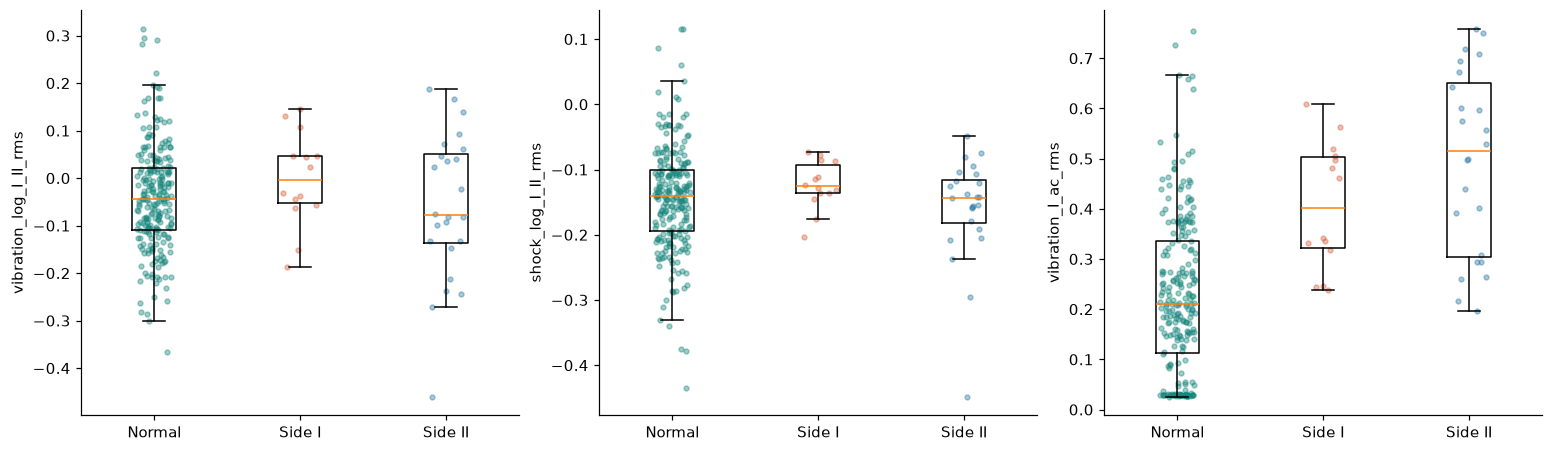

vibration_log_I_II_rms                     shock_log_I_II_rms  \
                           min    median       max                min   
label                                                                   
Normal               -0.365463 -0.044321  0.314813          -0.435634   
Side I               -0.187854 -0.004316  0.144946          -0.203603   
Side II              -0.460010 -0.078674  0.187295          -0.448135   

                             
           median       max  
label                        
Normal  -0.140834  0.116068  
Side I  -0.125584 -0.072391  
Side II -0.143272 -0.048643

In [13]:
fig,axes=plt.subplots(1,3,figsize=(14,4)); rng=np.random.default_rng(SEED)
for ax,col in zip(axes,['vibration_log_I_II_rms','shock_log_I_II_rms','vibration_I_ac_rms']):
    values=[train_features.loc[train_features.label.eq(label),col].dropna() for label in CLASSES]
    ax.boxplot(values,showfliers=False,tick_labels=CLASSES)
    for i,(label,v) in enumerate(zip(CLASSES,values),1): ax.scatter(i+rng.uniform(-.12,.12,len(v)),v,s=10,alpha=.4,color=COLORS[label])
    ax.set(ylabel=col)
plt.show()
display(train_features.groupby('label')[['vibration_log_I_II_rms','shock_log_I_II_rms']].agg(['min','median','max']))

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-7" style="color: black;"><b>Section 7: Outlier Review and Feature Dependence</b></h2>
</div>

This section identifies unusual recordings and assesses whether feature differences can be entangled with speed or redundant summaries.

<blockquote><h3 id="7-1"><b>7.1 Normal-Reference Robust Outlier Screen</b></h3></blockquote>

Train Normal medians and MAD values define an exploratory screen on a small feature subset. Absolute scores above 3.5 flag review cases. Zero-MAD features are excluded; known faults and operational extremes are retained rather than removed.

In [14]:
CORE=['vibration_I_ac_rms','vibration_II_ac_rms','shock_I_ac_rms','shock_II_ac_rms',
      'vibration_log_I_II_rms','shock_log_I_II_rms','speed_kmh_rising']
normal=train_features.loc[train_features.label.eq('Normal'),CORE]
reference=normal.median(); mad=(normal-reference).abs().median()
display(pd.DataFrame({'normal_median':reference,'MAD':mad,'excluded_zero_MAD':mad.eq(0)}))
robust=.67448975*(features[CORE]-reference)/mad.replace(0,np.nan)
outliers=features[[]].copy()
outliers['flag_count']=robust.abs().gt(3.5).sum(axis=1)
outliers['max_abs_robust_z']=robust.abs().max(axis=1)
outliers['flagged_features']=robust.abs().gt(3.5).apply(lambda s:', '.join(s.index[s]),axis=1)
outliers=outliers.reset_index()
outliers['label']=[labels.loc[n,'label'] if s=='Train' else 'Unlabelled' for s,n in zip(outliers.dataset,outliers.filename)]
display(outliers.groupby(['dataset','label']).flag_count.agg(files='size',flagged_files=lambda s:s.gt(0).sum()))
display(outliers.nlargest(12,'max_abs_robust_z'))

,normal_median,MAD,excluded_zero_MAD
vibration_I_ac_rms,0.209995,0.116561,False
vibration_II_ac_rms,0.210055,0.117758,False
shock_I_ac_rms,1.187014,0.052719,False
shock_II_ac_rms,1.379960,0.092980,False
vibration_log_I_II_rms,-0.044321,0.064865,False
shock_log_I_II_rms,-0.140834,0.046956,False
speed_kmh_rising,29.270004,17.626097,False


files  flagged_files
dataset label                           
Test    Unlabelled     68              2
Train   Normal        234              6
        Side I         14              0
        Side II        24              4

,dataset,filename,flag_count,max_abs_robust_z,flagged_features,label
196,Train,Train214.csv,2,4.904649,"shock_I_ac_rms, shock_log_I_II_rms",Normal
91,Train,Train12.csv,1,4.414171,shock_log_I_II_rms,Side II
99,Train,Train127.csv,1,4.322500,vibration_log_I_II_rms,Side II
222,Train,Train238.csv,1,3.958360,shock_I_ac_rms,Normal
62,Test,Test66.csv,1,3.916153,vibration_II_ac_rms,Unlabelled
246,Train,Train26.csv,1,3.773720,vibration_II_ac_rms,Side II
277,Train,Train42.csv,1,3.734401,vibration_log_I_II_rms,Normal
156,Train,Train179.csv,1,3.715151,vibration_II_ac_rms,Side II
248,Train,Train261.csv,1,3.690227,shock_log_I_II_rms,Normal
131,Train,Train156.csv,1,3.674550,shock_log_I_II_rms,Normal


<blockquote><h3 id="7-2"><b>7.2 Speed and Amplitude Relationships</b></h3></blockquote>

Scatter plots and within-class correlations assess speed confounding. These are associations only; dividing amplitude by speed without a physical model is not justified by this screen.

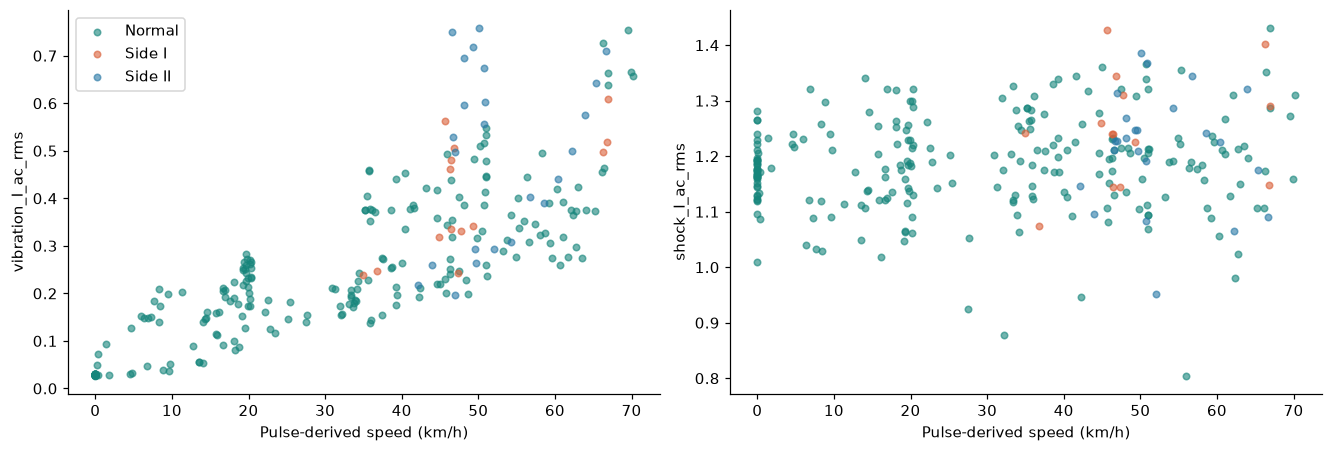

speed_kmh_rising,vibration_I_ac_rms,vibration_II_ac_rms,shock_I_ac_rms,shock_II_ac_rms,vibration_log_I_II_rms,shock_log_I_II_rms,speed_kmh_rising
label,,,,,,,
Normal,0.879526,0.856383,0.127043,0.120838,0.290841,-0.037481,1.0
Side I,0.554456,0.514852,0.114412,-0.114412,-0.275028,0.468647,1.0
Side II,0.197042,0.315790,-0.036538,0.135711,-0.559374,-0.099174,1.0


In [15]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,col in zip(axes,['vibration_I_ac_rms','shock_I_ac_rms']):
    for label in CLASSES:
        g=train_features.loc[train_features.label.eq(label)]
        ax.scatter(g.speed_kmh_rising,g[col],s=18,alpha=.6,label=label,color=COLORS[label])
    ax.set(xlabel='Pulse-derived speed (km/h)',ylabel=col)
axes[0].legend(); plt.show()
display(train_features.groupby('label').apply(lambda g:g[CORE].corr(method='spearman')['speed_kmh_rising'],include_groups=False))

<blockquote><h3 id="7-3"><b>7.3 Feature Redundancy and Case-Level Uncertainty</b></h3></blockquote>

Spearman correlations describe redundant feature families. Bootstrap intervals for median side asymmetry resample whole files within classes, not channels. Unknown source-session dependence and only 14 Side I cases limit these exploratory intervals.

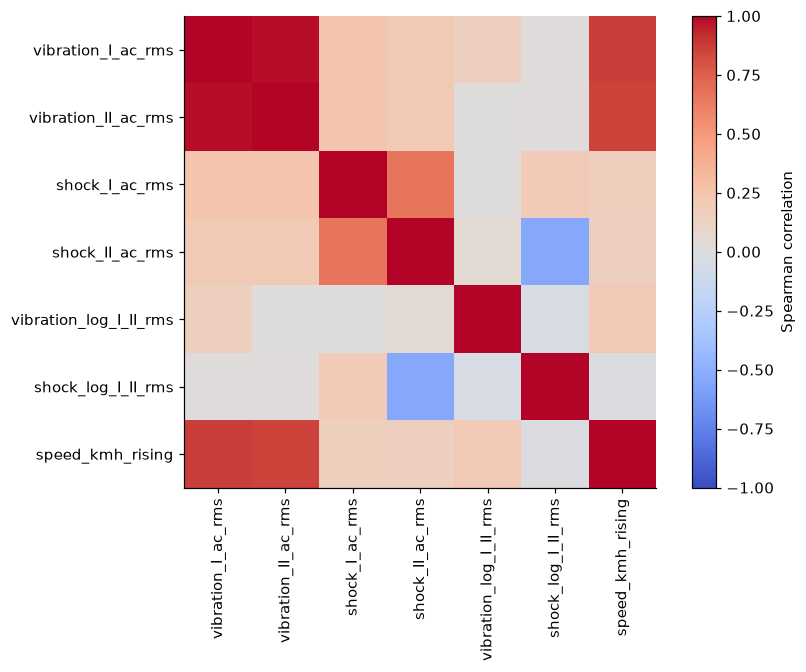

,label,feature,files,median,low_95,high_95
0,Normal,vibration_log_I_II_rms,234,-0.044321,-0.062009,-0.026637
1,Normal,shock_log_I_II_rms,234,-0.140834,-0.148436,-0.132279
2,Side I,vibration_log_I_II_rms,14,-0.004316,-0.055997,0.046207
3,Side I,shock_log_I_II_rms,14,-0.125584,-0.136361,-0.098327
4,Side II,vibration_log_I_II_rms,24,-0.078674,-0.132059,0.041104
5,Side II,shock_log_I_II_rms,24,-0.143272,-0.158299,-0.121186


In [16]:
corr=train_features[CORE].corr(method='spearman')
fig,ax=plt.subplots(figsize=(8,6)); im=ax.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm')
ax.set(xticks=range(len(CORE)),xticklabels=CORE,yticks=range(len(CORE)),yticklabels=CORE)
ax.tick_params(axis='x',rotation=90); fig.colorbar(im,ax=ax,label='Spearman correlation'); plt.show()
rng=np.random.default_rng(SEED); uncertainty=[]
for label in CLASSES:
    for col in ['vibration_log_I_II_rms','shock_log_I_II_rms']:
        x=train_features.loc[train_features.label.eq(label),col].dropna().to_numpy()
        medians=np.median(rng.choice(x,size=(2000,len(x)),replace=True),axis=1)
        lo,hi=np.quantile(medians,[.025,.975])
        uncertainty.append({'label':label,'feature':col,'files':len(x),'median':np.median(x),'low_95':lo,'high_95':hi})
display(pd.DataFrame(uncertainty))

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-8" style="color: black;"><b>Section 8: Train and Test Coverage</b></h2>
</div>

This section evaluates unlabelled Test coverage using Train reference distributions. Distribution differences do not reveal Test class labels or establish generalisation performance.

<blockquote><h3 id="8-1"><b>8.1 Feature Range and Median Shifts</b></h3></blockquote>

Test medians are compared with Train medians using Train IQR scaling. Counts outside Train ranges highlight extrapolation candidates without fitting a detector.

,train_median,test_median,median_shift_train_IQR,test_outside_train_range
vibration_II_band_100_500,0.235668,0.245482,0.067564,4
shock_I_kurtosis,12.369439,12.528066,0.067443,3
vibration_I_band_100_500,0.239483,0.251335,0.088222,2
shock_I_band_1500_5000,0.000066,0.000066,0.006776,2
vibration_II_ac_rms,0.240416,0.261323,0.086501,1
shock_I_spectral_centroid,217.692354,218.243286,0.120738,1
shock_I_peak,6.920801,6.927380,0.014334,1
vibration_II_band_0_100,0.537528,0.596124,0.215672,1
vibration_II_band_500_1500,0.154522,0.146482,-0.059147,1
vibration_I_crest,5.568880,5.318730,-0.132907,1


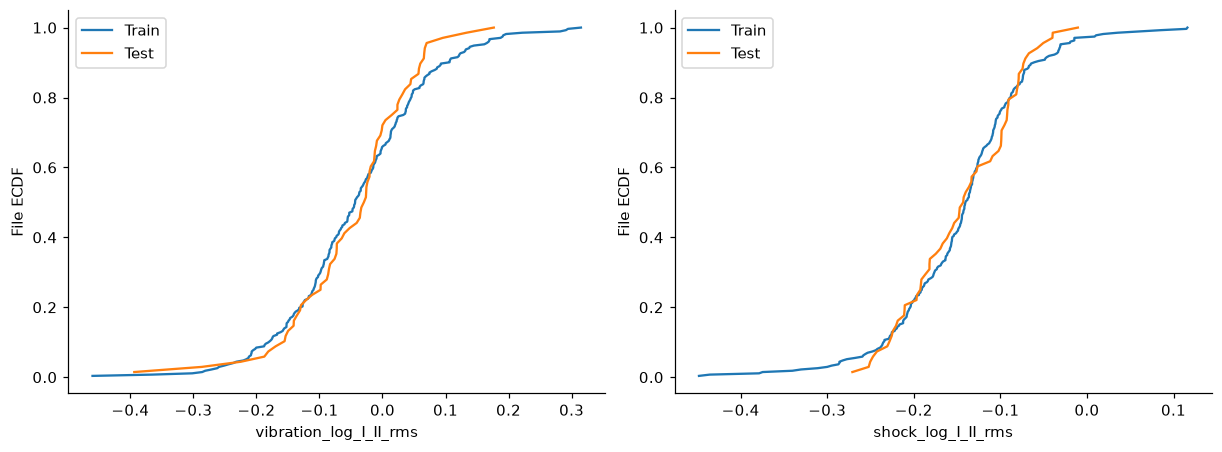

In [17]:
iqr=train_features[FEATURES].quantile(.75)-train_features[FEATURES].quantile(.25)
shift=pd.DataFrame({'train_median':train_features[FEATURES].median(),'test_median':test_features.median(),
 'median_shift_train_IQR':(test_features.median()-train_features[FEATURES].median())/iqr.replace(0,np.nan),
 'test_outside_train_range':((test_features<train_features[FEATURES].min())|(test_features>train_features[FEATURES].max())).sum()})
display(shift.sort_values('test_outside_train_range',ascending=False))
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,col in zip(axes,['vibration_log_I_II_rms','shock_log_I_II_rms']):
    for split,frame in [('Train',train_features),('Test',test_features)]:
        x=np.sort(frame[col].dropna()); ax.plot(x,np.arange(1,len(x)+1)/len(x),label=split)
    ax.set(xlabel=col,ylabel='File ECDF'); ax.legend()
plt.show()

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-9" style="color: black;"><b>Section 9: Validation Planning and Leakage Controls</b></h2>
</div>

This section prepares recording-level splits and identifies unresolved grouping and sensor-transfer issues. No classifier or Test prediction is produced.

<blockquote><h3 id="9-1"><b>9.1 Provisional Stratified File Folds</b></h3></blockquote>

Four stratified group folds keep exact acceleration duplicates together while retaining all three classes in each validation fold. All channels and windows from a file inherit its fold. Duplicate-label consistency and train/validation group separation are asserted. Source run, route, and session metadata would support stronger grouping beyond exact duplicates.

In [18]:
from sklearn.model_selection import StratifiedGroupKFold

fold_manifest=labels.join(quality.query("dataset == 'Train'").set_index('filename')[['acceleration_hash']],validate='one_to_one')
group_labels=fold_manifest.groupby('acceleration_hash').label.nunique()
assert group_labels.eq(1).all(), 'Identical acceleration recordings have conflicting labels; review before splitting.'
fold_manifest['fold']=-1
splitter=StratifiedGroupKFold(n_splits=4,shuffle=True,random_state=SEED)
for fold,(training,validation) in enumerate(splitter.split(fold_manifest,fold_manifest.label,groups=fold_manifest.acceleration_hash),1):
    fold_manifest.iloc[validation,fold_manifest.columns.get_loc('fold')]=fold
    assert set(fold_manifest.iloc[training].acceleration_hash).isdisjoint(fold_manifest.iloc[validation].acceleration_hash)
assert fold_manifest.groupby('acceleration_hash').fold.nunique().eq(1).all()
fold_counts=pd.crosstab(fold_manifest.fold,fold_manifest.label).reindex(columns=CLASSES,fill_value=0)
assert fold_counts.gt(0).all().all(), 'Every validation fold requires all three classes.'
display(fold_counts)
display(fold_manifest.loc[fold_manifest.acceleration_hash.duplicated(keep=False),['label','fold']])

label,Normal,Side I,Side II
fold,,,
1,58,4,6
2,59,3,6
3,59,3,6
4,58,4,6


,label,fold
filename,,
Train107.csv,Normal,1
Train115.csv,Normal,1
Train165.csv,Normal,2
Train187.csv,Normal,2


<blockquote><h3 id="9-2"><b>9.2 Modelling Handoff</b></h3></blockquote>

The planning table connects the task structure to later experiments. Band selection, balancing, scaling, and feature selection require training-fold-only decisions.

In [19]:
display(pd.DataFrame([
 ('Prediction unit','One Normal/Side I/Side II label per complete recording; channels and windows are not independent labels.'),
 ('Candidate families','Compare per-side RMS, shock impulsiveness, spectral bands, per-car localisation, and signed side contrasts.'),
 ('Minority classes','Report per-class precision/recall/F1 and confusion matrices alongside macro F1. Resampling and class weights belong inside training folds.'),
 ('Speed context','Validate pulse-to-speed conventions and compare class performance across speed ranges before speed normalisation.'),
 ('Spectral limits','A 1-second recording cannot establish stable long-term frequency behaviour; Welch spacing and windowing limit resolution.'),
 ('Wavelength inference','Speed divided by frequency is only a kinematic candidate under validated excitation assumptions, not proof of corrugation wavelength.'),
 ('Grouping','Seek route, source run, session, and vehicle identifiers. Filename order does not establish chronology.'),
 ('Sensor transfer','Inspect channel-specific scale and availability; a location-dependent shortcut may not transfer across vehicles.'),
 ('Target scope','No both-sides-fault class is supplied. Evidence from this dataset does not validate simultaneous bilateral fault recognition.'),
 ('Test discipline','Keep Test labels unknown and do not optimise thresholds or bands to a preferred Test result.')
],columns=['topic','requirement']))

,topic,requirement
0,Prediction unit,One Normal/Side I/Side II label per complete r...
1,Candidate families,"Compare per-side RMS, shock impulsiveness, spe..."
2,Minority classes,Report per-class precision/recall/F1 and confu...
3,Speed context,Validate pulse-to-speed conventions and compar...
4,Spectral limits,A 1-second recording cannot establish stable l...
5,Wavelength inference,Speed divided by frequency is only a kinematic...
6,Grouping,"Seek route, source run, session, and vehicle i..."
7,Sensor transfer,Inspect channel-specific scale and availabilit...
8,Target scope,No both-sides-fault class is supplied. Evidenc...
9,Test discipline,Keep Test labels unknown and do not optimise t...


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-10" style="color: black;"><b>Section 10: Verified Findings and Conclusions</b></h2>
</div>

This section records the completed audit and the conclusions supported by the saved results.

<blockquote><h3 id="10-1"><b>10.1 Reproducible Results Summary</b></h3></blockquote>

The summary reports observed file counts, data quality, duplicate groups, feature counts, and reference-screen flags without claiming model performance.

In [20]:
summary={'train_files':len(train_features),'test_files':len(test_features),'class_counts':labels.label.value_counts().to_dict(),
 'invalid_cells':int(quality[['missing','nonnumeric','infinite']].sum().sum()),
 'constant_acceleration_channels':int(quality.constant_acceleration_channels.sum()),
 'full_duplicate_files':len(duplicates),'acceleration_duplicate_files':len(acceleration_duplicates),
 'candidate_features':len(FEATURES),'test_features_outside_train_range':int(shift.test_outside_train_range.gt(0).sum()),
 'speed_proxy_min':float(speed.speed_kmh_rising.min()),'speed_proxy_max':float(speed.speed_kmh_rising.max()),
 'flagged_by_group':{str(k):int(v) for k,v in outliers.groupby(['dataset','label']).flag_count.apply(lambda s:s.gt(0).sum()).items()},
 'median_side_ratios':train_features.groupby('label')[['vibration_log_I_II_rms','shock_log_I_II_rms']].median().to_dict()}
print(json.dumps(summary,indent=2))

{
  "train_files": 272,
  "test_files": 68,
  "class_counts": {
    "Normal": 234,
    "Side II": 24,
    "Side I": 14
  },
  "invalid_cells": 0,
  "constant_acceleration_channels": 0,
  "full_duplicate_files": 4,
  "acceleration_duplicate_files": 4,
  "candidate_features": 43,
  "test_features_outside_train_range": 15,
  "speed_proxy_min": 0.0,
  "speed_proxy_max": 70.18391508739755,
  "flagged_by_group": {
    "('Test', 'Unlabelled')": 2,
    "('Train', 'Normal')": 6,
    "('Train', 'Side I')": 0,
    "('Train', 'Side II')": 4
  },
  "median_side_ratios": {
    "vibration_log_I_II_rms": {
      "Normal": -0.0443205580350485,
      "Side I": -0.0043155973656723145,
      "Side II": -0.0786738650948264
    },
    "shock_log_I_II_rms": {
      "Normal": -0.14083415450386783,
      "Side I": -0.12558408662949297,
      "Side II": -0.14327190927837236
    }
  }
}


<blockquote><h3 id="10-2"><b>10.2 Observed Results</b></h3></blockquote>

- All 272 Train and 68 Test recordings passed the 10,000-row and 129-column schema checks. The audit found 0 missing, non-numeric, or infinite cells and 0 constant acceleration channels across file-channel combinations.
- The observed Train labels are 234 Normal, 14 Side I, and 24 Side II. Always predicting Normal gives approximately 86.0% accuracy but only 0.308 macro F1 on these labels. Minority-class outcomes therefore require explicit reporting.
- The exact-duplicate checks identified 4 files in full numeric-recording duplicate groups and 4 files in acceleration-only duplicate groups. Both duplicate pairs occur within Train: `Train107.csv`/`Train115.csv` and `Train165.csv`/`Train187.csv`. The grouped fold plan keeps each pair together. Non-identical files may still share source-session dependence.
- The notebook constructs 43 recording-level candidate features while retaining channel-level summaries. Side medians, maximum RMS, spectral bands, and signed side ratios preserve information lost by whole-train averaging.
- Under the documented wheel geometry and the stated rising-edge convention, pulse-derived speed proxies range from approximately 0.00 to 70.18 km/h across supplied recordings. These values require calibration before physical speed or wavelength conclusions.
- 15 candidate features contain at least one Test value outside the observed Train range. This is a descriptive coverage result, not evidence of a particular Test class or model failure.
- Normal-reference outlier counts are reported separately by known Train class and unlabelled Test status in Section 7.1. Flagged files remain part of the dataset; the screen is not a trained classifier.

<blockquote><h3 id="10-3"><b>10.3 Limitations and Next Modelling Decisions</b></h3></blockquote>

The EDA preserves physical side identity and distinguishes file-level evidence from repeated samples and channels. Candidate features and outlier flags require validation; large amplitudes can represent genuine fault signatures and remain in the dataset.

The next modelling stage can compare compact side-aware features and richer spatial or spectral representations using complete held-out recordings. Source grouping, speed calibration, sensor saturation limits, and transfer across operating conditions remain unresolved. Test labels remain unknown, and no forecasts of future fault onset are established by one-second class-labelled recordings.